In [1]:
import pymc as pm
import arviz as az
import numpy as np
import pytensor as pt
import pytensor.tensor as tt
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
s = []
for i in np.arange(347):
    s.append(str(i))

In [3]:
data = pd.read_csv('EVI.csv', header=0, names=s)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,337,338,339,340,341,342,343,344,345,346
0,0.4560,NaN,0.3975,0.3183,0.3022,0.2870,0.2886,0.2236,0.2318,0.1911,...,0.2832,0.3471,0.3432,NaN,0.3971,0.4401,0.3606,0.3702,0.4172,0.4218
1,0.4652,NaN,0.3807,0.3194,0.2936,0.2985,0.2810,0.2221,0.2281,0.1891,...,0.2933,0.3547,0.3450,NaN,0.4069,0.4418,0.3606,0.3621,NaN,0.4294
2,0.4642,NaN,0.3748,0.3107,0.2918,0.3008,0.2810,0.2221,0.2277,0.1851,...,0.2804,0.3445,0.3450,NaN,0.4032,0.4490,0.3527,0.3750,NaN,0.4099
3,0.4576,NaN,0.3624,0.3076,0.2811,0.3083,0.2754,0.2134,0.2194,0.1820,...,0.2998,0.3517,0.3450,NaN,0.4006,0.4494,0.3551,0.3586,NaN,0.4326
4,0.4468,NaN,0.3600,0.2974,0.2681,0.3129,0.2698,0.2099,0.2194,0.1773,...,0.2891,0.3464,0.3468,NaN,0.3861,0.4378,0.3388,0.3273,NaN,0.4228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,0.4263,NaN,0.3711,0.3008,0.2867,0.3200,0.2856,0.2336,0.2417,0.2061,...,0.3174,0.4838,0.2843,NaN,0.3790,0.4730,0.4753,0.3612,0.4667,0.4319
11296,0.4412,NaN,0.3804,0.3055,0.3123,0.2833,0.2856,0.2278,0.2267,0.1967,...,0.2627,0.2769,0.1956,NaN,0.1590,0.3577,0.3272,0.6130,0.8339,0.6045
11297,0.4610,NaN,0.3835,0.3165,0.3134,0.2578,0.2923,0.2326,0.2267,0.1927,...,0.1562,0.1554,0.1581,NaN,0.1512,0.1602,0.3670,0.6244,0.8663,0.7845
11298,0.4566,NaN,0.3876,0.3174,0.3208,0.2883,0.2869,0.2288,0.2263,0.1930,...,0.1645,0.1945,0.1680,NaN,0.2586,NaN,0.3687,0.5850,0.5896,0.7060


In [5]:
def inpaint_nans(data):
    """
    Inpaint NaNs in a DataFrame using linear interpolation.
    """
    #return data.interpolate(method='linear', limit_direction='both', axis=0)
    aux = data.interpolate(method='linear', limit_direction='both', axis=0)
    return aux.interpolate(method='linear', limit_direction='both', axis=1)

ploteo datos de verdad

"Legacy"

In [6]:
''' 
#%% Model definition
basic_model = pm.Model()
samplesPerYear = 23 #Number of datapoints per year
sigma_err_prior = 1/0.05 #Estimate of EVI error variance
dummyData = np.zeros([0])
shared_data = T.shared(dummyData, borrow=True) #Sahred data definition - Theano

#%% Model definition
with basic_model:
        ## prior for 15-day EVI, U(0-1)
        x = pm.Uniform("x", 0, 1, shape=samplesPerYear)
        x = Tensor.cast(x, 'float64') #required for theano
        
        ## prior for observation process, Exp(sigma_err_prior)
        sigma_err = pm.Exponential("sigma_err", sigma_err_prior)

        @T.compile.ops.as_op(itypes=[Tensor.dvector],otypes=[Tensor.dvector]) #original
        def loredo(x = x, profile=True):
            L = shared_data.get_value(borrow=True).shape[0]
            out = np.zeros(L)
            k = 0
            while True:
                if (k+1)*samplesPerYear < L:
                    out[k*samplesPerYear:(k+1)*samplesPerYear] = x[0:samplesPerYear]
                    k = k+1
                else:
                    diff = (k+1)*samplesPerYear - L
                    out[k*samplesPerYear:(k+1)*samplesPerYear-diff] = x[0:samplesPerYear-diff]
                    break
            return out  
        loredo.grad = lambda *y: y[0]  # Here's the klutz, llama al grad pero es un bug
        loredo.shape = shared_data.get_value(borrow=True).shape[0]    
               
        ## likelihood
        observation = pm.Normal("obs", mu=loredo(x), tau=1/sigma_err, observed=shared_data)
'''

' \n#%% Model definition\nbasic_model = pm.Model()\nsamplesPerYear = 23 #Number of datapoints per year\nsigma_err_prior = 1/0.05 #Estimate of EVI error variance\ndummyData = np.zeros([0])\nshared_data = T.shared(dummyData, borrow=True) #Sahred data definition - Theano\n\n#%% Model definition\nwith basic_model:\n        ## prior for 15-day EVI, U(0-1)\n        x = pm.Uniform("x", 0, 1, shape=samplesPerYear)\n        x = Tensor.cast(x, \'float64\') #required for theano\n        \n        ## prior for observation process, Exp(sigma_err_prior)\n        sigma_err = pm.Exponential("sigma_err", sigma_err_prior)\n\n        @T.compile.ops.as_op(itypes=[Tensor.dvector],otypes=[Tensor.dvector]) #original\n        def loredo(x = x, profile=True):\n            L = shared_data.get_value(borrow=True).shape[0]\n            out = np.zeros(L)\n            k = 0\n            while True:\n                if (k+1)*samplesPerYear < L:\n                    out[k*samplesPerYear:(k+1)*samplesPerYear] = x[0:sam

Version 2025

defino subset de datos para probar

In [7]:
nPixelsWindow = 24
trainWindowLength = 23*10
samplesPerYear = 23

In [8]:
dataSubset = data.iloc[:nPixelsWindow, :trainWindowLength]

In [9]:
dataSubset = inpaint_nans(dataSubset)

chequeo que no haya NaNs

In [10]:
np.isnan(dataSubset).sum().sum()

np.int64(0)

In [11]:
dataSubset.shape

(24, 230)

In [12]:
coords = {'timeSeriesTrainlength': np.arange(trainWindowLength),
          'pixel': np.arange(nPixelsWindow),
          'samplesPerYear': np.arange(samplesPerYear)}
t = trainWindowLength
selPixel = 4 # centroal pixel of the window

In [13]:
coords

{'timeSeriesTrainlength': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172

version normales correlacionadas pixel per pixel

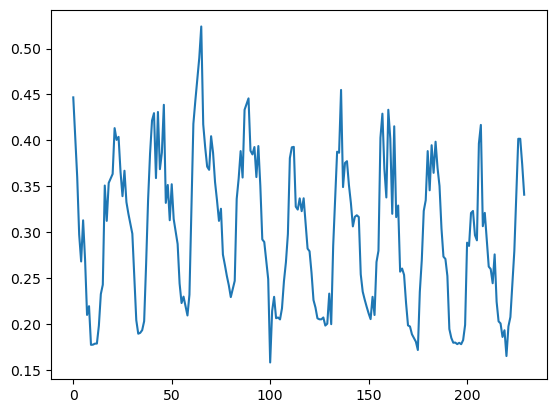

In [14]:
plt.plot(dataSubset.iloc[selPixel,:].values)

In [15]:
#%% Model definition
sigma_err = 0.05

with pm.Model() as modeNormCorr:
        
        # cov = np.eye(samplesPerYear)
        L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
        cov = pm.Deterministic('cov', L.dot(L.T))

        # mu = 0.3 + np.zeros(samplesPerYear)
        mus = pm.Normal('mus', mu=0.3, sigma=0.3, shape=samplesPerYear)
        x = pm.MvNormal("x", mu=mus, cov=cov)
        # y = pm.Uniform("y", 0, 1, shape=0)
        y = []
        # print(x[0:4].eval())
        # print(samplesPerYear)

        ciclos = (t) // (samplesPerYear)
        resto = (t) % (samplesPerYear)

        # print(ciclos)
        # print(resto)

        for i in range(ciclos):
            # y = pm.math.concatenate([y, x], axis=0) 
            y = pm.math.concatenate([y, x], axis=0) 
        
        y = pm.math.concatenate([y, x[0:resto]], axis=0)
        # print(x.shape.eval())
        obs = pm.Normal("obs", mu=y, sigma=sigma_err, observed=dataSubset.iloc[selPixel,:].values)

In [16]:
with modeNormCorr:
    trace_modeNormCorr = pm.sample() #target_accept=0.9

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [packed_L, mus, x]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 642 seconds.
There were 1973 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


guardo la traza

In [17]:
trace_modeNormCorr.to_netcdf("trace_modeNormCorr_10years.nc")

'trace_modeNormCorr_10years.nc'

estudio la traza

In [18]:
#az.summary(trace_modeNormCorr, round_to=2)

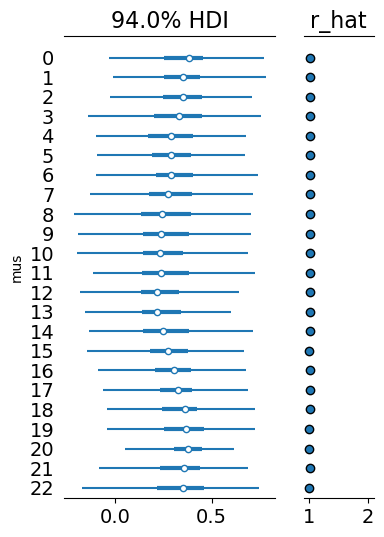

In [19]:
ax = az.plot_forest(
    trace_modeNormCorr,
    var_names=["mus"],
    r_hat=True,
    combined=True,
    figsize=(4, 6),
    labeller=az.labels.NoVarLabeller(),
)
ax[0].set_ylabel("mus");

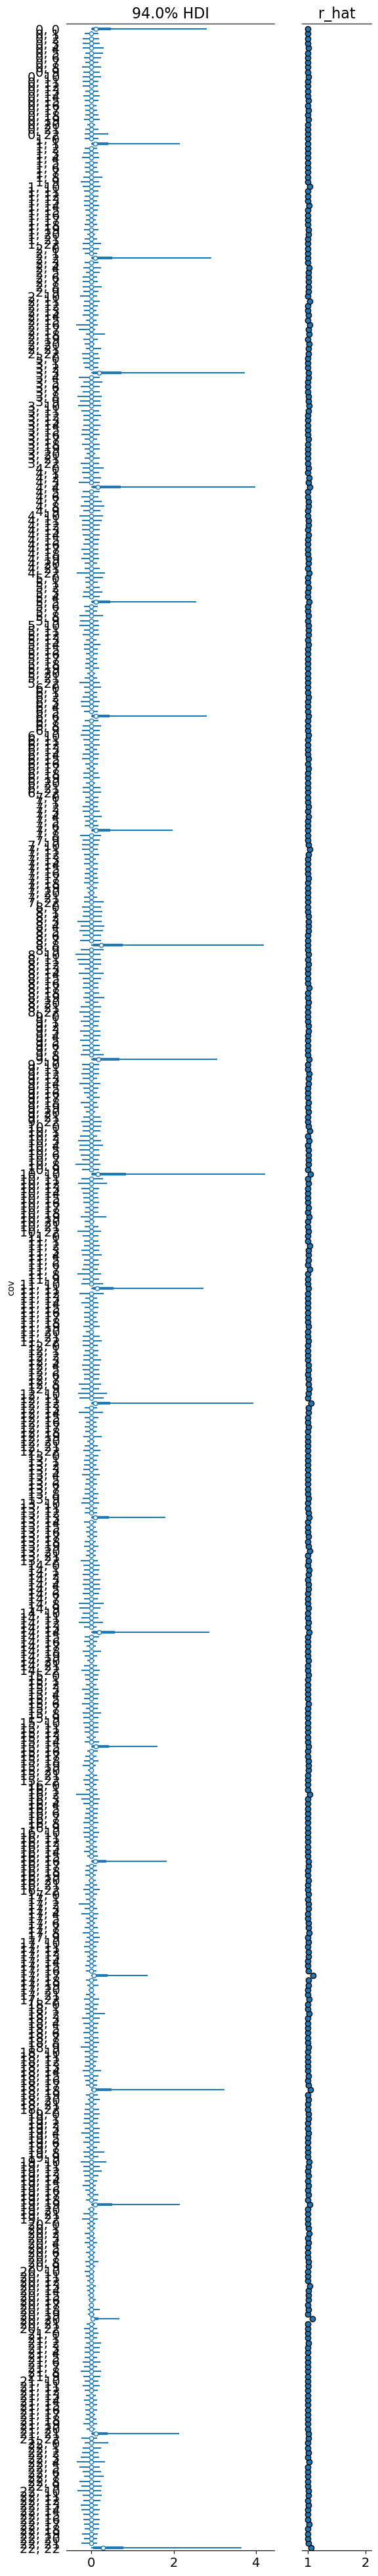

In [20]:
ax = az.plot_forest(
    trace_modeNormCorr,
    var_names=["cov"],
    r_hat=True,
    combined=True,
    figsize=(6, 50),
    labeller=az.labels.NoVarLabeller(),
)
ax[0].set_ylabel("cov");

evaluo matriz de corelacion

In [21]:
cov_trace = trace_modeNormCorr.posterior.cov.stack(stacked=['chain', 'draw']).values
cov_trace_mean = cov_trace.mean(axis=2)

In [22]:
import plotly.express as px

fig = px.imshow(cov_trace_mean)
fig.show()

prediccion

In [23]:
with modeNormCorr:
    ppc_modeNormCorr = pm.sample_posterior_predictive(trace_modeNormCorr, var_names=["obs"])

Sampling: [obs]


Output()

### version normales correlacionadas basadas en (https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/multilevel_modeling.html)

version fiteo todos los pixeles (creo que no conviene)

In [ ]:
#%% Model definition
sigma_err = 0.05

with pm.Model(coords=coords) as HierarchichalModel:
        
        '''
         floor_idx = pm.MutableData("floor_idx", floor_measure, dims="obs_id")
        county_idx = pm.MutableData("county_idx", county, dims="obs_id")

        # Priors
        mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0)
        sigma_a = pm.Exponential("sigma_a", 1)

        mu_b = pm.Normal("mu_b", mu=0.0, sigma=10.0)
        sigma_b = pm.Exponential("sigma_b", 1)

        # Random intercepts
        alpha = pm.Normal("alpha", mu=mu_a, sigma=sigma_a, dims="county")
        # Random slopes
        beta = pm.Normal("beta", mu=mu_b, sigma=sigma_b, dims="county")

        # Model error
        sigma_y = pm.Exponential("sigma_y", 1)

        # Expected value
        y_hat = alpha[county_idx] + beta[county_idx] * floor_idx

        # Data likelihood
        y_like = pm.Normal("y_like", mu=y_hat, sigma=sigma_y, observed=log_radon, dims="obs_id")
            '''

        inputData = pm.Data("inputData", dataSubset, dims=('pixel','timeSeriesTrainlength'))

        L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
        cov = pm.Deterministic('cov', L.dot(L.T))

        #mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0, dims=("samplesPerYear"))
        #sigma_a = pm.Exponential("sigma_a", 1, dims=("samplesPerYear"))

        mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0, dims=("samplesPerYear")) #, dims=("samplesPerYear"))
        sigma_a = pm.Exponential("sigma_a", 5, dims=("samplesPerYear")) #, dims=("samplesPerYear"))
    
        ''' 
        # version no centrada
        mus = pm.Normal('mus', mu=mu_a, sigma=sigma_a, dims=('pixel',"samplesPerYear"))
        x = pm.MvNormal("x", mu=mus, cov=cov)
        '''

        # version centrada
        mus_ = pm.Normal('mus_', mu=0, sigma=1, dims=('pixel',"samplesPerYear"))
        mus = pm.Deterministic('mus', mu_a + mus_ * sigma_a, dims=('pixel',"samplesPerYear"))
        x = pm.MvNormal("x", mu=mus, cov=cov)


        #print(x.shape.eval())

        # y = pm.Uniform("y", 0, 1, shape=0)

        # print(x[0:4].eval())
        # print(samplesPerYear)

        ciclos = (t) // (samplesPerYear)
        resto = (t) % (samplesPerYear)

        #print(ciclos)
        #print(resto)

        y = x
        for i in range(ciclos-1): 
            #y = pm.math.concatenate([y, x], axis=0) #oiginal
            y = pm.math.concatenate([y, x], axis=1) 
        
        z = pm.math.concatenate([y, x[:,0:resto]], axis=1)
        #print(y.shape.eval())
        #print(x[:,0:resto].shape.eval())
        #print(z.shape.eval())
        obs = pm.Normal("obs", mu=z, sigma=sigma_err, observed=inputData, dims=('pixel','timeSeriesTrainlength'))

version todo repetido sin diferenciacion por pixel (creo que si conviene)

In [24]:
#%% Model definition 
sigma_err = 0.05

with pm.Model(coords=coords) as HierarchichalModel:
        
        inputData = pm.Data("inputData", dataSubset, dims=('pixel','timeSeriesTrainlength'))

        L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
        cov = pm.Deterministic('cov', L.dot(L.T))

        mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0, dims=("samplesPerYear")) #, dims=("samplesPerYear"))
        sigma_a = pm.Exponential("sigma_a", 5, dims=("samplesPerYear")) #, dims=("samplesPerYear"))
    
        ''' 
        # version no centrada
        mus = pm.Normal('mus', mu=mu_a, sigma=sigma_a, dims=('pixel',"samplesPerYear"))
        x = pm.MvNormal("x", mu=mus, cov=cov)
        '''

        # version centrada
        mus_ = pm.Normal('mus_', mu=0, sigma=1, dims=("samplesPerYear"))
        mus = pm.Deterministic('mus', mu_a + mus_ * sigma_a, dims=("samplesPerYear"))
        x = pm.MvNormal("x", mu=mus, cov=cov)


        #print(x.shape.eval())

        # y = pm.Uniform("y", 0, 1, shape=0)

        # print(x[0:4].eval())
        # print(samplesPerYear)

        ciclos = (t) // (samplesPerYear)
        resto = (t) % (samplesPerYear)

        #print(ciclos)
        #print(resto)

        y = x
        for i in range(ciclos-1): 
            #y = pm.math.concatenate([y, x], axis=0) #oiginal
            y = pm.math.concatenate([y, x], axis=0) 
        
        z = pm.Deterministic('z', pm.math.concatenate([y, x[:resto]], axis=0))
        #print(y.shape.eval())
        #print(x[:,0:resto].shape.eval())
        #print(z.shape.eval())
        obs = pm.Normal("obs", mu=z, sigma=sigma_err, observed=inputData, dims=('pixel','timeSeriesTrainlength'))

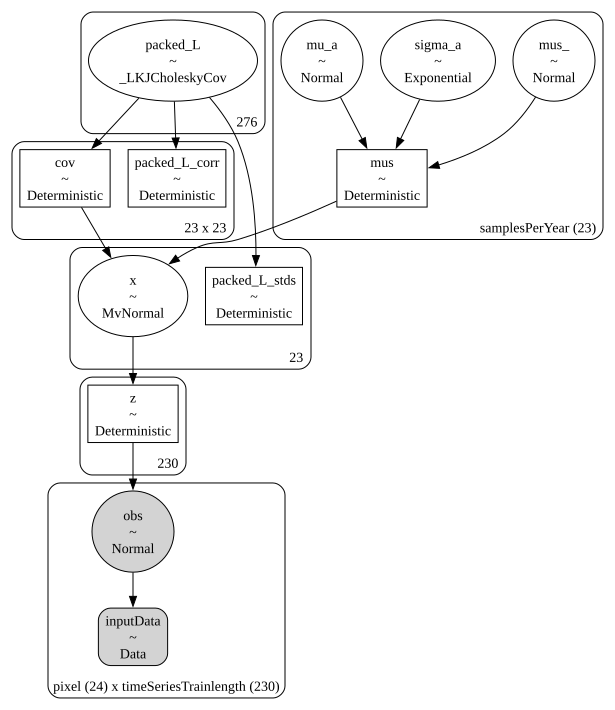

In [25]:
pm.model_to_graphviz(HierarchichalModel)

In [ ]:
with HierarchichalModel:
    print(z.shape.eval())
    print(z.shape.eval() == dataSubset.shape)


In [26]:
with HierarchichalModel:
    pm.sample_prior_predictive()

Sampling: [mu_a, mus_, obs, packed_L, sigma_a, x]


In [27]:
with HierarchichalModel:
    trace_HierarchichalModel = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [packed_L, mu_a, sigma_a, mus_, x]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 795 seconds.
There were 2290 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


guardo traza

In [28]:
trace_HierarchichalModel.to_netcdf("trace_HierarchichalModel_todosMezclados_27_10years.nc")
# idata = az.from_netcdf("filename.nc")

'trace_HierarchichalModel_todosMezclados_27_10years.nc'

evaluo traza

In [ ]:
#az.summary(trace_HierarchichalModel, round_to=2)

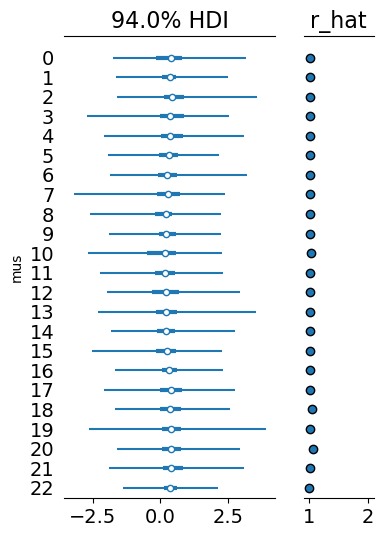

In [31]:
ax = az.plot_forest(
    trace_HierarchichalModel,
    var_names=["mus"],
    r_hat=True,
    combined=True,
    figsize=(4, 6),
    labeller=az.labels.NoVarLabeller(),
)
ax[0].set_ylabel("mus");

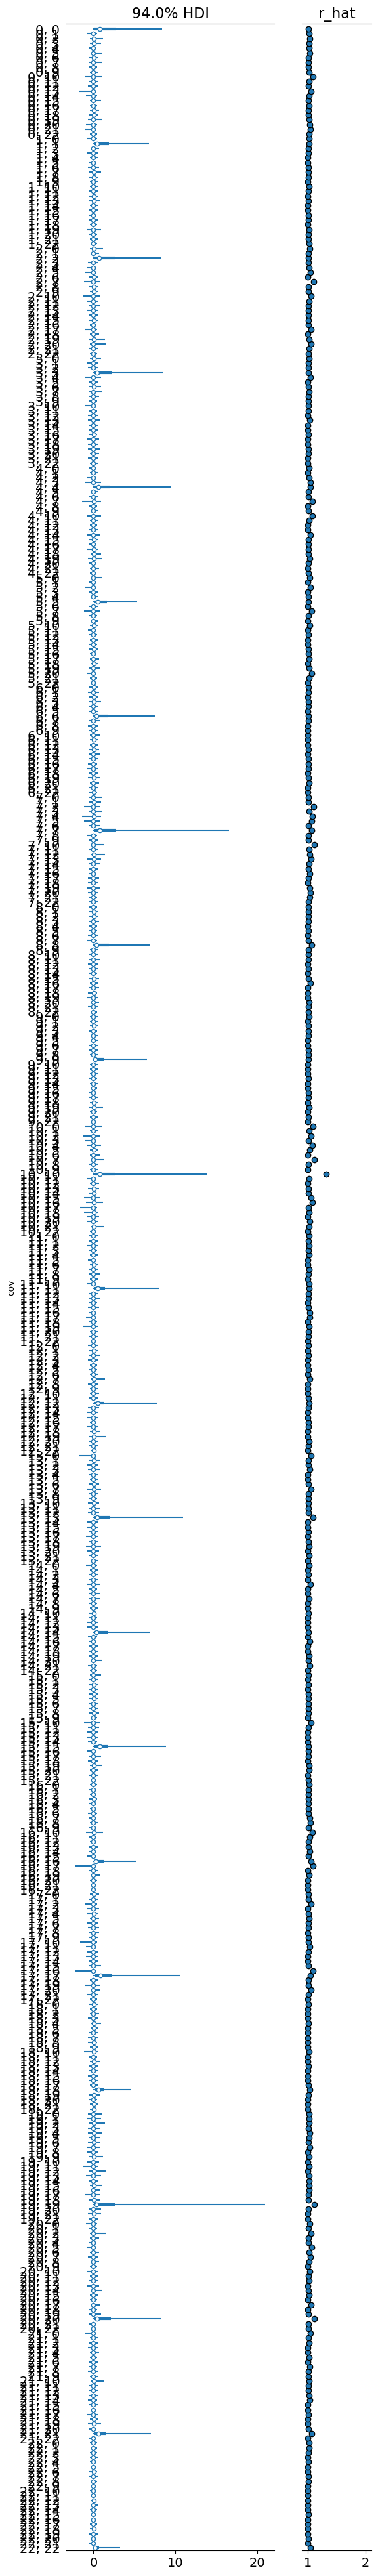

In [32]:
ax = az.plot_forest(
    trace_HierarchichalModel,
    var_names=["cov"],
    r_hat=True,
    combined=True,
    figsize=(6, 50),
    labeller=az.labels.NoVarLabeller(),
)
ax[0].set_ylabel("cov");

Evaluo como da la posterior de la matriz de covarianza (que se supone que es la posta de este modelo) 

In [33]:
#opcion 1
cov_trace_mean = trace_HierarchichalModel.posterior.cov.stack(stacked=['chain', 'draw']).mean(dim='stacked')

In [34]:
import plotly.express as px

fig = px.imshow(cov_trace_mean.values)
fig.show()

No parece haber grandes valores fuera de la diagonal :( (ni dentro de la diagonal para el modelo pixel a pixel :( :()

Prediccion

In [35]:
with HierarchichalModel:
    ppc_HierarchichalModel = pm.sample_posterior_predictive(trace_HierarchichalModel, var_names=["obs"])

Sampling: [obs]


Output()

In [36]:
ppc_HierarchichalModel.posterior_predictive.obs

<xarray.DataArray 'obs' (chain: 4, draw: 1000, pixel: 24,
                         timeSeriesTrainlength: 230)> Size: 177MB
array([[[[0.30276278, 0.44873712, 0.49248412, ..., 0.49988818,
          0.44505787, 0.4441099 ],
         [0.40488601, 0.38917366, 0.32832237, ..., 0.42179906,
          0.33991117, 0.43075889],
         [0.35859822, 0.35168422, 0.47465116, ..., 0.32752576,
          0.43403892, 0.37153466],
         ...,
         [0.41082511, 0.33284202, 0.42802239, ..., 0.42856034,
          0.39984854, 0.36377895],
         [0.45541297, 0.39896262, 0.39633368, ..., 0.4125171 ,
          0.44651723, 0.40737252],
         [0.37222216, 0.38078453, 0.39392797, ..., 0.38397392,
          0.40659056, 0.40166313]],

        [[0.3398892 , 0.3784144 , 0.3635814 , ..., 0.38992309,
          0.37987566, 0.47033285],
         [0.49481135, 0.29108082, 0.41169777, ..., 0.44556877,
          0.35085659, 0.38079207],
         [0.40921682, 0.28973959, 0.31445689, ..., 0.45503423,
          0.40530179, 0.41713131],
...
         [0.38303227, 0.37735368, 0.27631385, ..., 0.4245403 ,
          0.31220595, 0.32557124],
         [0.4280021 , 0.37191904, 0.31994195, ..., 0.42473766,
          0.4424395 , 0.31550837],
         [0.41922159, 0.31872505, 0.27878171, ..., 0.32963582,
          0.34119448, 0.42549118]],

        [[0.37538797, 0.3014387 , 0.30187046, ..., 0.35784129,
          0.42165619, 0.35415817],
         [0.43695868, 0.36287732, 0.35780193, ..., 0.43629034,
          0.42651424, 0.3625286 ],
         [0.35309518, 0.35434985, 0.37139744, ..., 0.45172389,
          0.42292979, 0.36043605],
         ...,
         [0.41068912, 0.37403705, 0.33014167, ..., 0.40046228,
          0.31171677, 0.35202161],
         [0.3879927 , 0.40021319, 0.25132099, ..., 0.41578016,
          0.35082462, 0.40791969],
         [0.48924422, 0.29980234, 0.39501828, ..., 0.43858592,
          0.32643933, 0.31960041]]]], shape=(4, 1000, 24, 230))
Coordinates:
  * chain                  (chain) int64 32B 0 1 2 3
  * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
  * pixel                  (pixel) int64 192B 0 1 2 3 4 5 ... 18 19 20 21 22 23
  * timeSeriesTrainlength  (timeSeriesTrainlength) int64 2kB 0 1 2 ... 228 229

<ErrorbarContainer object of 3 artists>

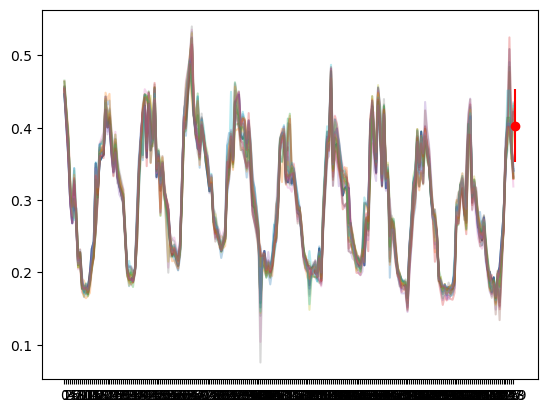

In [37]:
# fecha_est = (t+1) % (samplesPerYear) #estimacion t+1
fecha_est = (t) % (samplesPerYear)

# est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
# est_ = ppc.posterior_predictive.obs.stack(stacked=['chain', 'draw']).values
# est = est_[fecha_est,:]



est_HierarchichalModel = ppc_HierarchichalModel.posterior_predictive.obs.stack(stacked=['chain', 'draw']).sel(pixel = selPixel).sel(timeSeriesTrainlength = fecha_est)


plt.plot(dataSubset.iloc[selPixel,:])
plt.plot(dataSubset.T, alpha = 0.3)

plt.errorbar(x=t, y=est_HierarchichalModel.mean(), yerr=est_HierarchichalModel.std(), fmt='o', color='red')

In [38]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot selected pixel time series
# fig.add_trace(go.Scatter(
#     y=dataSubset.iloc[selPixel, :],
#     mode='lines',
#     name='Selected Pixel'
# ))

# Plot all time series (transpose of dataSubset)
# for i in range(dataSubset.shape[0]):
#     fig.add_trace(go.Scatter(
#         y=dataSubset.iloc[i, :],
#         mode='lines',
#         opacity=0.3,
#         line=dict(color='gray'),
#         name='All Neighbour Pixels (window)' if i == 0 else None,
#         showlegend=(i == 0)
#     ))

# Plot all time series of neigbouring pixels
for i in range(10):
    fig.add_trace(go.Scatter(
        y=data.iloc[i, :],
        mode='lines',
        opacity=0.3,
        line=dict(color='green'),
        name='All Neighbour Pixels (window)' if i == 0 else None,
        showlegend=(i == 0)
    ))


# Plot whole time series of selected pixel
fig.add_trace(go.Scatter(
    y=inpaint_nans(data).iloc[selPixel, :trainWindowLength],
    mode='lines',
    line=dict(color='blue'),
    opacity=1,
    name='Selected Pixel'
))

# Error bar (equivalent to plt.errorbar)
fig.add_trace(go.Scatter(
    x=[t],
    y=[est_HierarchichalModel.mean()],
    error_y=dict(
        type='data',
        array=[est_HierarchichalModel.std()],
        visible=True
    ),
    mode='markers',
    marker=dict(color='red', size=8),
    name='Estimate'
))

# Optional: reco or reco_ can be plotted here
# fig.add_trace(go.Scatter(y=reco_, mode='lines', name='Reco'))

fig.update_layout(
    title='EVI Time Series',
    xaxis_title='Time',
    yaxis_title='EVI',
    template='plotly_white'
)

fig.show()

grafico resumen normales corr vs hirarchichal

In [39]:
est_HierarchichalModel = ppc_HierarchichalModel.posterior_predictive.obs.stack(stacked=['chain', 'draw']).sel(pixel = selPixel).sel(timeSeriesTrainlength = fecha_est)
#est_modeNormCorr = ppc_modeNormCorr.posterior_predictive.obs.stack(stacked=['chain', 'draw']).sel(obs_dim_2 = fecha_est)
est_modeNormCorr = ppc_modeNormCorr.posterior_predictive.obs.stack(stacked=['chain', 'draw']).sel(obs_dim_0 = fecha_est)



In [43]:
est_HierarchichalModel.quantile([0.25, 0.75], dim='stacked')

<xarray.DataArray 'obs' (quantile: 2)> Size: 16B
array([0.36832676, 0.43723714])
Coordinates:
  * quantile  (quantile) float64 16B 0.25 0.75

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot whole time series of selected pixel
fig.add_trace(go.Scatter(
    y=inpaint_nans(data).iloc[selPixel, :trainWindowLength],
    mode='lines',
    line=dict(color='blue'),
    opacity=1,
    name='Selected Pixel'
))

#### ------------------------ Inicio Normales Corr

# Error bar (equivalent to plt.errorbar)
fig.add_trace(go.Scatter(
    x=[t],
    y=[est_modeNormCorr.mean()],
    error_y=dict(
        type='data',
        array=[est_modeNormCorr.std()],
        visible=True
    ),
    mode='markers',
    marker=dict(color='orange', size=8),
    name='Estimate correlated Normal'
))



#### ------------------------ Fin Normales Corr




#### ------------------------ Inicio Jerarquico

# Plot all time series of neigbouring pixels
for i in range(nPixelsWindow):
    fig.add_trace(go.Scatter(
        y=data.iloc[i, :],
        mode='lines',
        opacity=0.3,
        line=dict(color='green'),
        name='All Neighbour Pixels (window)' if i == 0 else None,
        showlegend=(i == 0)
    ))


# Error bar (equivalent to plt.errorbar)
fig.add_trace(go.Scatter(
    x=[t+0.5],
    y=[est_HierarchichalModel.mean()],
    error_y=dict(
        type='data',
        array=[est_HierarchichalModel.std()], #std
        #array=[est_HierarchichalModel.mean() est_HierarchichalModel.quantile([0.1, 0.9], dim='stacked').values],
        #array = [0.1, 0.5],
        
        visible=True
    ),
    mode='markers',
    marker=dict(color='red', size=8),
    name='Estimate Hierarchical'
))

#### ------------------------ Fin jerarquico

fig.update_layout(
    title='EVI Time Series',
    xaxis_title='Time',
    yaxis_title='EVI',
    template='plotly_white'
)

fig.show()

Definicion de la clase para predecir

In [ ]:
class LoredoModel:
    def __init__(self, trainData, samples_per_year=23, sigma_err=0.05):
        self.trainData = trainData
        self.samples_per_year = samples_per_year
        self.sigma_err = sigma_err
        self.model = None
        self.trace = None

    def trainUniform(self):
        with pm.Model() as model:
            x = pm.Uniform("x", 0, 1, shape=self.samples_per_year)
            y = []

            ciclos = (len(self.trainData)) // (self.samples_per_year)
            resto = (len(self.trainData)) % (self.samples_per_year)

            for i in range(ciclos):
                y = pm.math.concatenate([y, x], axis=0) 

            y = pm.math.concatenate([y, x[0:resto]], axis=0)
            obs = pm.Normal("obs", mu=y, sigma=self.sigma_err, observed=self.trainData)

            self.model = model

    def trainCorrelatedNormal(self):
        with pm.Model() as model:
            cov = np.eye(samplesPerYear)

            L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
            cov = pm.Deterministic('cov', L.dot(L.T))

            mus = pm.Normal('mus', mu=0.3, sigma=0.1, shape=samplesPerYear)
            x = pm.MvNormal("x", mu=mus, cov=cov)
            
            y = []

            ciclos = (t) // (samplesPerYear)
            resto = (t) % (samplesPerYear)

            for i in range(ciclos):
                y = pm.math.concatenate([y, x], axis=0) 
            
            y = pm.math.concatenate([y, x[0:resto]], axis=0)
            obs = pm.Normal("obs", mu=y, sigma=sigma_err, observed=trainData)
            self.model = model

    def sample(self):
        with self.model:
            self.trace = pm.sample(target_accept=0.9)

    def plot_trace(self):
        pm.traceplot(self.trace)
        plt.show()

    def posterior_predictive(self):
        with self.model:
            ppc = pm.sample_posterior_predictive(self.trace, var_names=["obs"])
        return ppc
    
    def estimation(self, ppc):
        fecha_est = (len(self.trainData) + 1) % (self.samples_per_year)
        est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
        est = est_[fecha_est, :]
        return est
    
    def plot_posterior_predictive(self, ppc):
        fecha_est = (len(self.trainData) + 1) % (self.samples_per_year)
        est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
        est = est_[fecha_est, :]
        plt.plot(self.trainData)
        reco_ = loredo_det(self.trace.posterior.x.mean(dim='chain').values, len(self.trainData) + 1, self.samples_per_year)
        plt.plot(reco_)
        plt.errorbar(x=len(self.trainData) + 1, y=est.mean(), yerr=est.std(), fmt='o', color='red')
        plt.show()

    def run(self):
        self.trainUniform()
        self.sample()
        ppc = self.posterior_predictive()
        est = self.estimation(ppc)
        return est
        # self.plot_posterior_predictive(ppc)
        # self.plot_trace()


In [ ]:
# Example usage
loredo_model = LoredoModel(testSeries[:200])
est = loredo_model.run()

In [ ]:
plt.hist(est)